## ThinkDSP

This notebook contains code examples from Chapter 2: Harmonics

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

## Waveforms and harmonics

Create a triangle signal and plot a 3 period segment.

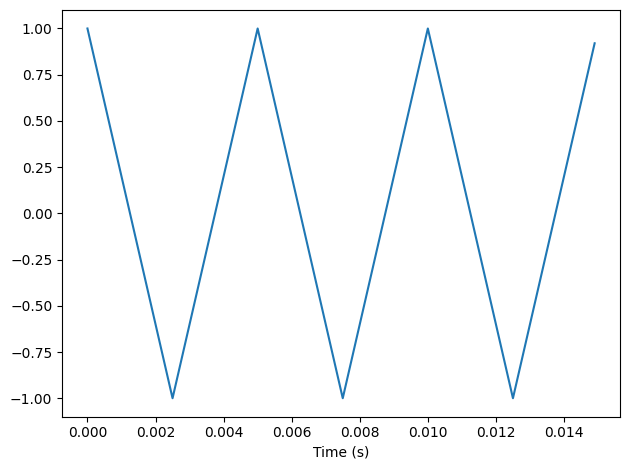

In [2]:
from thinkdsp import TriangleSignal
from thinkdsp import decorate

signal = TriangleSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [3]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

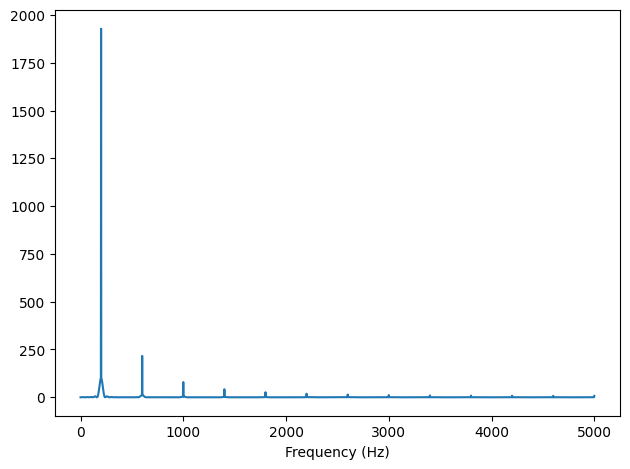

In [4]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

Make a square signal and plot a 3 period segment.

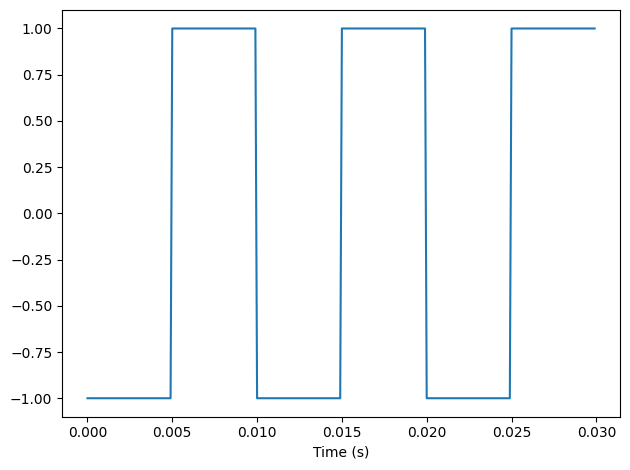

In [5]:
from thinkdsp import SquareSignal

signal = SquareSignal(100)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [6]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

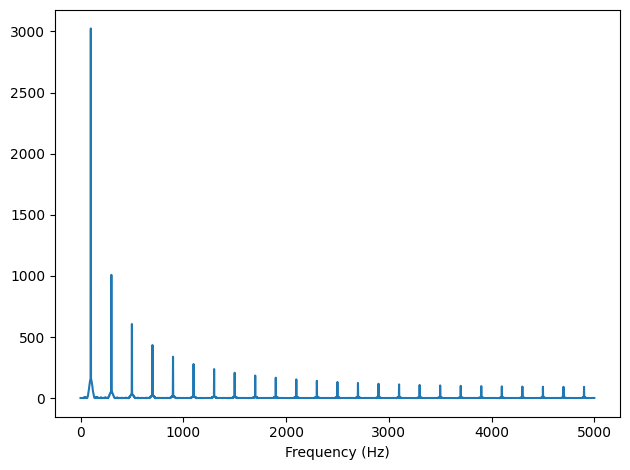

In [7]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

Create a sawtooth signal and plot a 3 period segment.

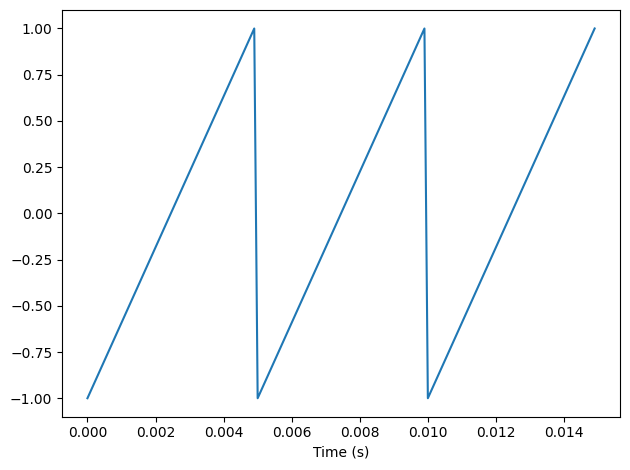

In [8]:
from thinkdsp import SawtoothSignal

signal = SawtoothSignal(200)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a wave and play it.

In [9]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.apodize()
wave.make_audio()

Compute its spectrum and plot it.

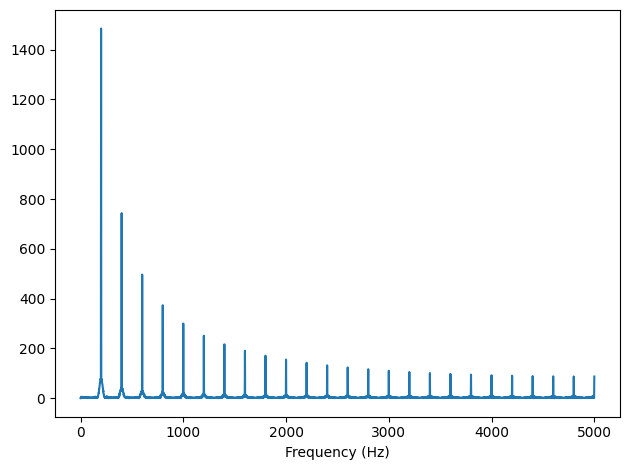

In [10]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

### Aliasing

Make a cosine signal at 4500 Hz, make a wave at framerate 10 kHz, and plot 5 periods.

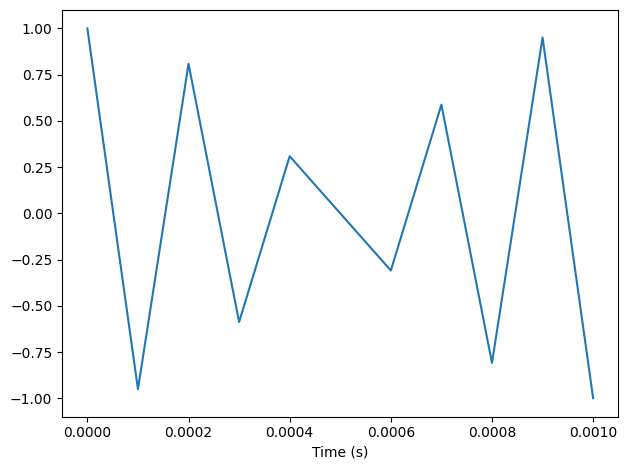

In [11]:
from thinkdsp import CosSignal

signal = CosSignal(4500)
duration = signal.period*5
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a cosine signal at 5500 Hz, make a wave at framerate 10 kHz, and plot the same duration.

With framerate 10 kHz, the folding frequency is 5 kHz, so a 4500 Hz signal and a 5500 Hz signal look exactly the same.

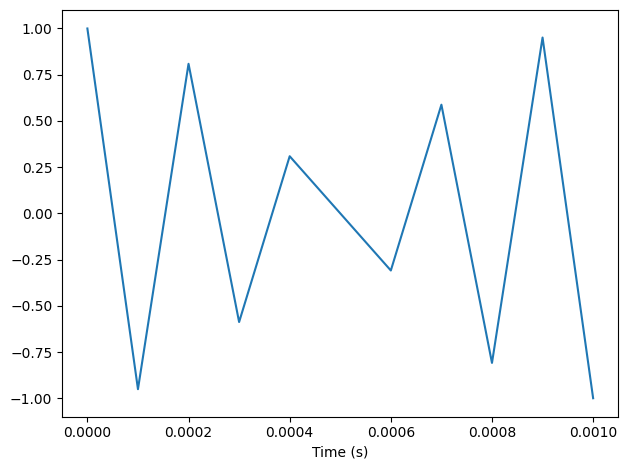

In [12]:
signal = CosSignal(5500)
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

Make a triangle signal and plot the spectrum.  See how the harmonics get folded.

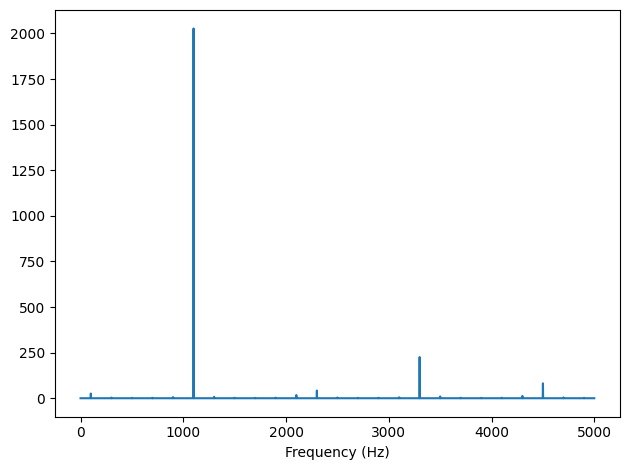

In [13]:
signal = TriangleSignal(1100)
segment = signal.make_wave(duration=0.5, framerate=10000)
spectrum = segment.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

## Amplitude and phase

Make a sawtooth wave.

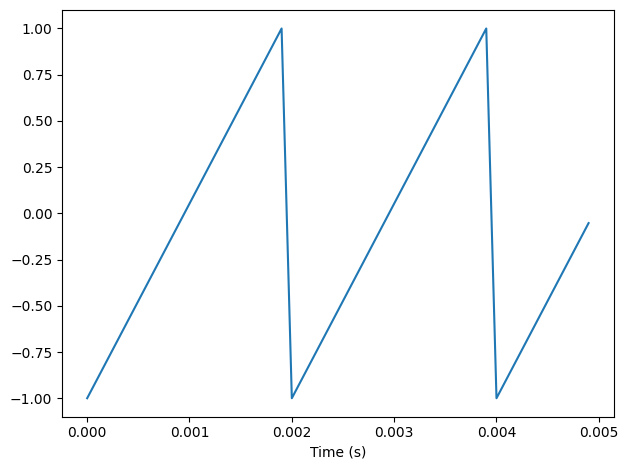

In [14]:
signal = SawtoothSignal(500)
wave = signal.make_wave(duration=1, framerate=10000)
segment = wave.segment(duration=0.005)
segment.plot()
decorate(xlabel='Time (s)')

Play it.

In [15]:
wave.make_audio()

Extract the wave array and compute the real FFT (which is just an FFT optimized for real inputs).

In [16]:
import numpy as np

hs = np.fft.rfft(wave.ys)
hs

array([ 5.11590770e-13+0.00000000e+00j,  2.19700679e-13-1.34559298e-13j,
       -2.09548671e-13-6.74603523e-14j, ...,
        4.19606174e-13+3.46000979e-14j, -5.63280756e-13+5.74915022e-14j,
       -5.26315789e+02+0.00000000e+00j])

Compute the frequencies that match up with the elements of the FFT.

In [17]:
n = len(wave.ys)                 # number of samples
d = 1 / wave.framerate           # time between samples
fs = np.fft.rfftfreq(n, d)
fs

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 4.998e+03, 4.999e+03,
       5.000e+03])

Plot the magnitudes vs the frequencies.

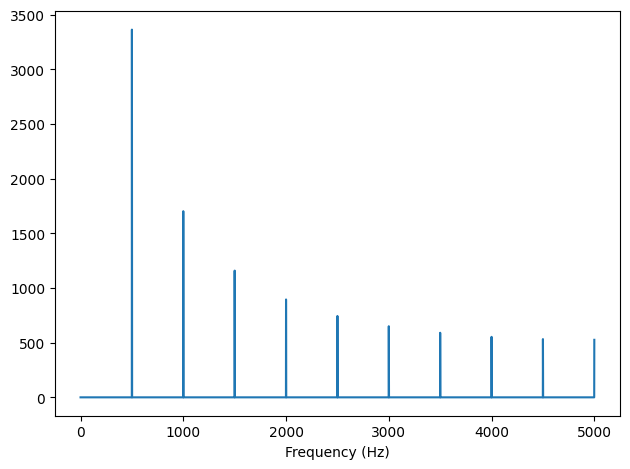

In [18]:
import matplotlib.pyplot as plt

magnitude = np.absolute(hs)
plt.plot(fs, magnitude)
decorate(xlabel='Frequency (Hz)')

Plot the phases vs the frequencies.

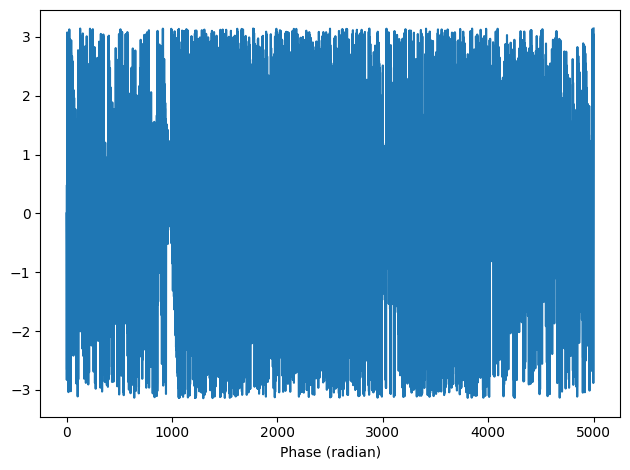

In [19]:
angle = np.angle(hs)
plt.plot(fs, angle)
decorate(xlabel='Phase (radian)')

## What does phase sound like?

Shuffle the phases.

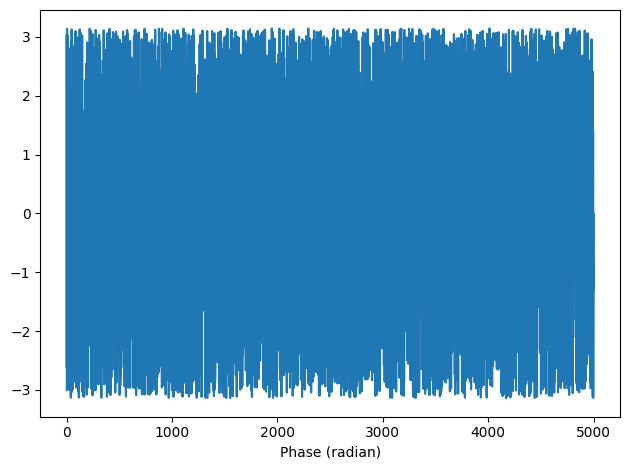

In [20]:
import random
random.shuffle(angle)
plt.plot(fs, angle)
decorate(xlabel='Phase (radian)')

Put the shuffled phases back into the spectrum.  Each element in `hs` is a complex number with magitude $A$ and phase $\phi$, with which we can compute $A e^{i \phi}$

In [21]:
i = complex(0, 1)
spectrum = wave.make_spectrum()
spectrum.hs = magnitude * np.exp(i * angle)

Convert the spectrum back to a wave (which uses irfft).

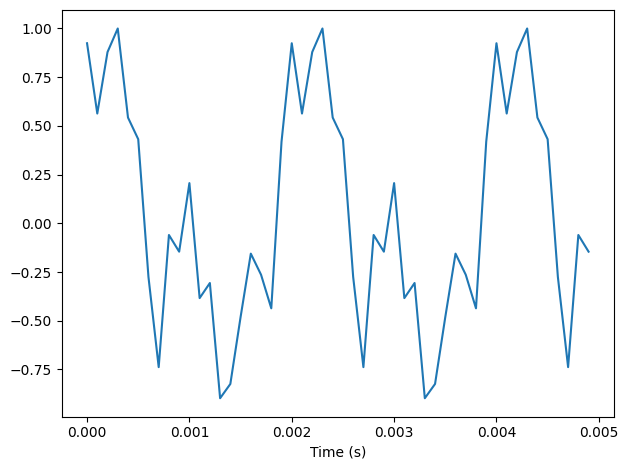

In [22]:
wave2 = spectrum.make_wave()
wave2.normalize()
segment = wave2.segment(duration=0.005)
segment.plot()
decorate(xlabel='Time (s)')

Play the wave with the shuffled phases.

In [23]:
wave2.make_audio()

For comparison, here's the original wave again.

In [24]:
wave.make_audio()

Although the two signals have different waveforms, they have the same frequency components with the same amplitudes.  They differ only in phase.

## Aliasing interaction

The following interaction explores the effect of aliasing on the harmonics of a sawtooth signal.

In [25]:
def view_harmonics(freq, framerate):
    """Plot the spectrum of a sawtooth signal.

    freq: frequency in Hz
    framerate: in frames/second
    """
    signal = SawtoothSignal(freq)
    wave = signal.make_wave(duration=0.5, framerate=framerate)
    spectrum = wave.make_spectrum()
    spectrum.plot(color='C0')
    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')
    display(wave.make_audio())

In [26]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider1 = widgets.FloatSlider(min=100, max=10000, value=100, step=100)
slider2 = widgets.FloatSlider(min=5000, max=40000, value=10000, step=1000)
interact(view_harmonics, freq=slider1, framerate=slider2);

interactive(children=(FloatSlider(value=100.0, description='freq', max=10000.0, min=100.0, step=100.0), FloatS…

# **Упражнение 2.1**
Для Jupyter надо загрузить chap02.ipynb и примеры.

# **Упражнение 2.2**
Пилообразный сигнал линейно нарастает от — 1 до 1, а затем резко
падает до —1 и повторяется. См. http://en.wikipedia.org/wiki/Sawtooth_wave (Ha англ. яз.).

Напишите класс, называемый SawtoothSignal, расширяющий signal и предоставляющий evaluate для оценки пилообразного
сигнала.

Вычислите спектр пилообразного сигнала. Как соотносится его
гармоническая структура с треугольным и прямоугольным сигналами?

In [27]:
from thinkdsp import Sinusoid

class SawtoothSignal(Sinusoid):
  def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / np.pi / 2
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)
        return ys

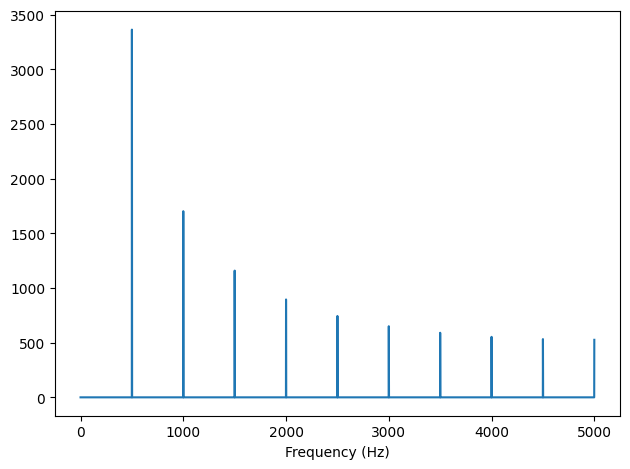

In [28]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

# **Упражнение 2.3**
Создайте прямоугольный сигнал 1100 Гц и вычислите wave с выборками 10 000 кадров в секунду. Постройте спектр и убедитесь, что
большинство гармоник «завернуты» из-за биений. Слышны ли последствия этого при проигрывании?

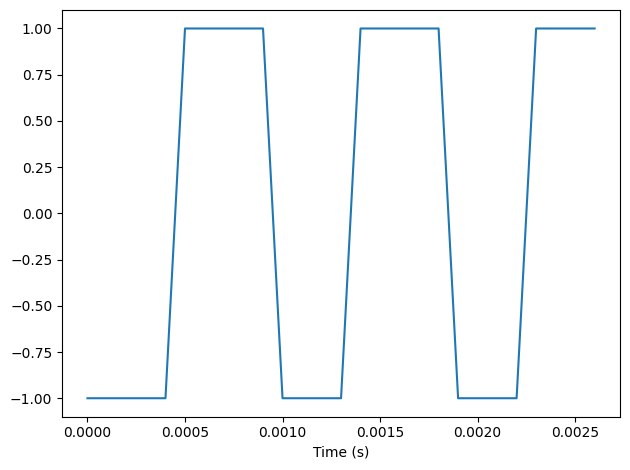

In [29]:
signal = SquareSignal(1100)
duration = signal.period*3
segment = signal.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

In [30]:
wave = signal.make_wave(duration=0.5, framerate=10000)
wave.make_audio()

Биения искажают звук.

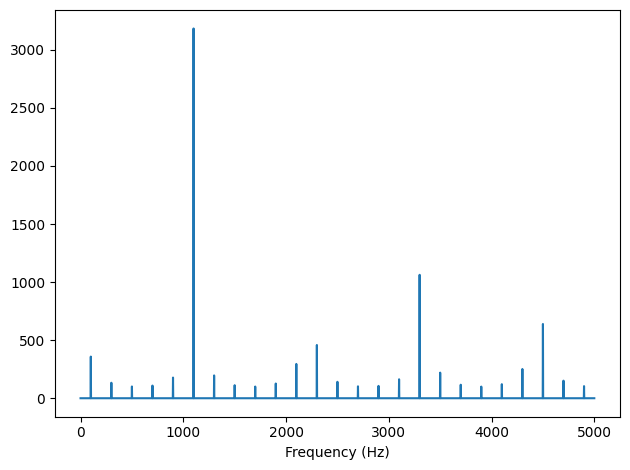

In [31]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

Пики (по порядку): 1100, 3300, 4500(10000-5500), 2300 (10000-7700), 100(10000-9900) Гц.

5000 Гц - частота заворота.

# **Упражнение 2.4**
Возьмите объект Spectrum и распечатайте несколько первых знaчений spectrums. Убедитесь, что они начинаются с нуля, то есть
Spectrum.hs[0] — амплитуда компоненты с частотой 0. Но что это
значит?
Проведите такой эксперимент:
1. Создайте треугольный сигнал с частотой 440 Гц и wave длительностью 0,01 секунд. Распечатайте сигнал.
2. Создайте объект Spectrum и распечатайте Spectrum.hs [0].
Каковы амплитуда и фаза этого компонента?
3. Установите Spectrum.hs[0] = 100. Как эта операция повлияет на сигнал? Подсказка: Spectrum дает метод, называемый
make_wave, вычисляющий wave, соответствующий Spectrum.

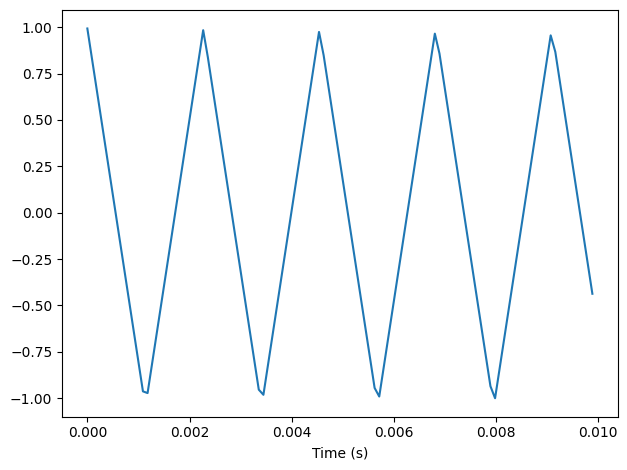

In [32]:
signal = TriangleSignal(440)
segment = signal.make_wave(duration=0.01)
segment.plot()
decorate(xlabel='Time (s)')

In [33]:
spectrum = segment.make_spectrum()
spectrum.hs[0]

np.complex128(1.0436096431476471e-14+0j)

Амплитуда - 1.0436096431476471e-14

Фаза - 0j

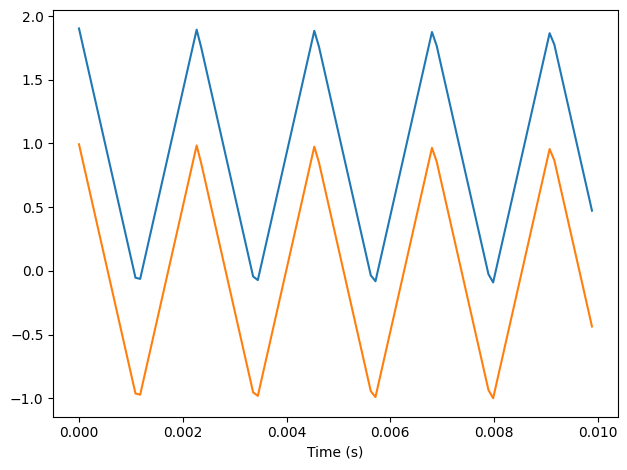

In [34]:
spectrum.hs[0]=100
spectrum.make_wave().plot()
segment.plot()
decorate(xlabel='Time (s)')

Сигнал сдвинулся на 100 единиц вверх, т. е. установка spectrum.hs[0]=100 добавила постоянное смещение

# **Упражнение 2.5**
Напишите функцию, принимающую Spectrum как параметр и изменяющую его делением каждого элемента hs на соответствующую частоту из fs. Подсказка: поскольку деление на ноль не определено, надо задать Spectrum.hs[0] = 0.
Проверьте эту функцию, используя прямоугольный, треугольный ИЛИ пилообразный сигналы:
1. Вычислите Spectrum и распечатайте его.
2. Измените Spectrum, вновь используя свою функцию, и распечатайте его.
3. Используйте Spectrum.make wave, чтобы сделать wave из измененного Spectrum, и прослушайте его. Как эта операция повлияла на сигнал?

In [35]:
def change_spectr(spectrum):
  spectrum.hs[0] = 0
  spectrum.hs[1:] = spectrum.hs[1:] / spectrum.fs[1:]

Проверим на прямоугольном сигнале:

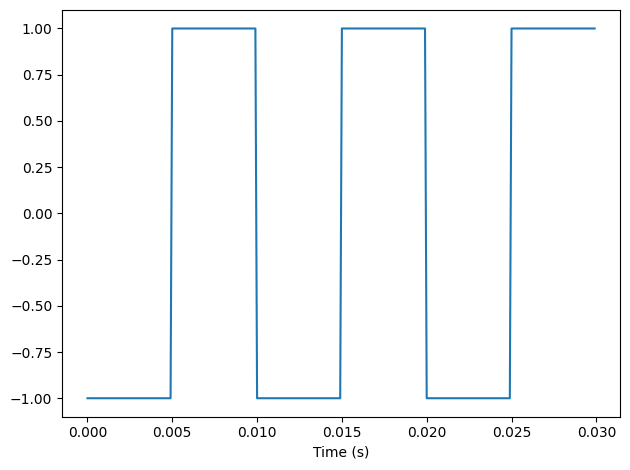

In [36]:
square = SquareSignal(100)
duration = square.period*3
segment = square.make_wave(duration, framerate=10000)
segment.plot()
decorate(xlabel='Time (s)')

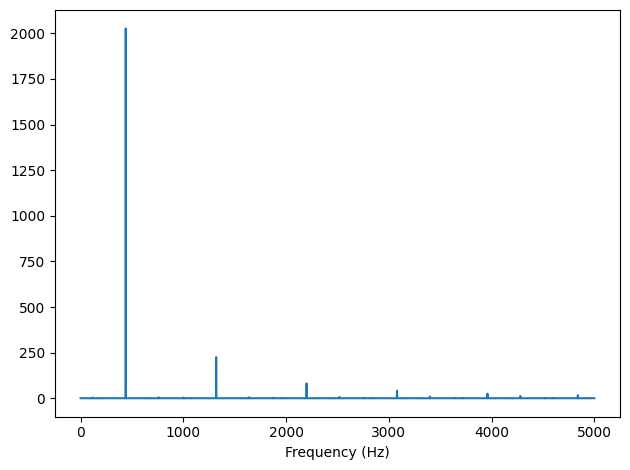

In [37]:
wave = signal.make_wave(duration=0.5, framerate=10000)
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

# **Упражнение 2.6**
У треугольных и прямоугольных сигналов есть только нечетные
гармоники; в пилообразном сигнале есть и четные, и нечетные гармоники. Гармоники прямоугольных и пилообразных сигналов уменьшаются пропорционально 1/f гармоники треугольных сигналов — пропорционально 1/f^2. Можно ли найти сигнал, состоящий из четных и нечетных гармоник, спадающих пропорционально 1/f^2?
Подсказка: для этого есть два способа. Можно собрать желаемый
сигнал из синусоид, а можно взять сигнал со спектром, похожим на
необходимый, и изменять его параметры.

Для того, чтобы получить требуемый сигнал, можно взять пилообразный сигнал, который уже имеет нужные гармоники и текущие амплитуды разделить на f, чтобы получить требуемый спад.

In [39]:
sawtooth = SawtoothSignal(200)


In [ ]:
spectrum = segment.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)')

# Свойства преобразования Фурье

Преобразование Фурье позволяет перейти от временного представления сигнала к частотному.

---

## 1. **Линейность**  
Преобразование Фурье линейно: преобразование суммы функций равно сумме их преобразований, а умножение функции на константу приводит к умножению преобразования на ту же константу.    
$$
\mathcal{F}(a \cdot f + b \cdot g) = a \cdot \mathcal{F}(f) + b \cdot \mathcal{F}(g)
$$

---

## 2. **Теорема о свертке**  
Свертка двух функций во временной области соответствует умножению их преобразований Фурье в частотной области, и наоборот.   
$$
\mathcal{F}(f * g) = \mathcal{F}(f) \cdot \mathcal{F}(g)
$$  


---

## 3. **Равенство Парсеваля**  
Энергия сигнала сохраняется при преобразовании Фурье. Интеграл квадрата модуля функции равен интегралу квадрата модуля её спектра.    
$$
\int_{-\infty}^{\infty} |f(x)|^2 dx = \int_{-\infty}^{\infty} |\mathcal{F}(f)(\omega)|^2 d\omega
$$

---

## 4. **Сдвиг сигнала и модуляция**  
**Сдвиг во времени:**  
Сдвиг функции на величину t во временной области приводит к умножению её спектра на фазовый множитель.  
$$
\mathcal{F}(f(x - x_0)) = e^{-2\pi j \omega t} \cdot \mathcal{F}(f)(\omega)
$$  

**Сдвиг по частоте (модуляция):**  
Умножение функции на комплексную экспоненту \(e^{2\pi j \omega_0 x}\) сдвигает её спектр на \(\omega_0\).  
$$
\mathcal{F}\left(e^{2\pi j \omega_0 x} \cdot f(x)\right) = \mathcal{F}(f)(\omega - \omega_0)
$$

---

## 5. **Масштабирование**  
Сжатие функции во временной области приводит к растяжению её спектра, и наоборот.  
**Формула (для \(a \neq 0\)):**  
$$
\mathcal{F}(f(a x)) = \frac{1}{|a|} \, \mathcal{F}(f)\left(\frac{\omega}{a}\right)
$$

---

## 6. **Дифференцирование и интегрирование**  
Преобразование производной функции дает перед образом множитель jw. Преобразование производной n-го порядка дает множитель (jw)^n. Соответственно преобразование первообразной функции (считая превообразную как интеграл от -inf с переменым верхним пределом) дает множитель (jw)^(-1).

